# Εργαστήριο 1: Ανάπτυξη Συστήματος Υποστήριξης Αποφάσεων (DSS) με την Python
## Το Σενάριο (Business Problem)

Είστε ο Tactical Manager μιας μεγάλης αλυσίδας ξενοδοχείων. Το πρόβλημα που καλείστε να λύσετε είναι το υψηλό ποσοστό **Ακυρώσεων Κρατήσεων (Cancellations)**, το οποίο προκαλεί τεράστια απώλεια εσόδων.

**Dataset:** [Hotel Booking Demand — Kaggle (Jesse Mostipak)](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

> Τα δεδομένα περιέχουν **119.390 κρατήσεις** από δύο πορτογαλικά ξενοδοχεία (City Hotel & Resort Hotel) για την περίοδο 2015–2017. Κάθε γραμμή αντιπροσωπεύει μία κράτηση με 32 χαρακτηριστικά: από τον τύπο δωματίου και τον αριθμό επισκεπτών, μέχρι τον χρόνο προ-κράτησης (`lead_time`) και αν τελικά ακυρώθηκε (`is_canceled`).

Στόχος αυτού του εργαστηρίου είναι να εφαρμόσουμε το μοντέλο του **Herbert Simon**:
1. **Intelligence:** Θα φορτώσουμε και θα καθαρίσουμε τα ιστορικά δεδομένα (Data Cleaning).
2. **Design:** Θα αναλύσουμε τα πρότυπα συμπεριφοράς των πελατών (Correlation, What-If).
3. **Choice:** Θα προτείνουμε συγκεκριμένες πολιτικές (πολυπλοκότητα εγγυήσεων, όρια χρόνου) για να μειώσουμε τις ακυρώσεις.

### Τα Εργαλεία μας (Python Libraries)
Σε ένα Σύστημα Υποστήριξης Αποφάσεων (DSS), χρειαζόμαστε εργαλεία για να μετατρέψουμε τα ακατέργαστα δεδομένα σε χρήσιμη πληροφορία. Στην Python, αυτό γίνεται κυρίως με 3 βιβλιοθήκες:

1. **Pandas (`pd`)**: Είναι το "έξυπνο Excel" της Python. Μας επιτρέπει να φορτώνουμε τεράστια σύνολα δεδομένων (DataFrames), να τα φιλτράρουμε, να τα ομαδοποιούμε και να τα μετασχηματίζουμε με λίγες γραμμές κώδικα.
2. **Matplotlib (`plt`)**: Η βασική βιβλιοθήκη για τη δημιουργία γραφημάτων. Μας δίνει τον απόλυτο έλεγχο πάνω σε κάθε στοιχείο (άξονες, τίτλοι, χρώματα).
3. **Seaborn (`sns`)**: Χτίζεται πάνω στην Matplotlib, αλλά έχει δημιουργηθεί ειδικά για στατιστική ανάλυση. Με τη Seaborn μπορούμε να φτιάξουμε εντυπωσιακά και πολύπλοκα γραφήματα (όπως Heatmaps) πολύ εύκολα, βοηθώντας τον Tactical Manager να δει αμέσως τα μοτίβα.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Φόρτωση του dataset (Hotel Booking Demand από το Kaggle)
df = pd.read_csv('hotel_bookings.csv')

## Intelligence Phase: Γνωριμία με τα Δεδομένα
### Βήμα 1: Έλεγχος των Δεδομένων (Data Inspection)
Πριν ξεκινήσουμε την ανάλυση, πρέπει να "γνωρίσουμε" τα δεδομένα μας. Στη Λήψη Αποφάσεων δεν μπορούμε να προχωρήσουμε αν δεν κατανοήσουμε το περιβάλλον του προβλήματος (Intelligence Phase). 

Οι βασικές ερωτήσεις που κάνουμε στα δεδομένα μας μέσω της Pandas είναι:
* `df.shape`: Πόσες παραγγελίες/κρατήσεις (γραμμές) και πόσα χαρακτηριστικά (στήλες) έχουμε;
* `df.info()`: Τι τύπου είναι τα δεδομένα μας; Έχουμε κείμενο, αριθμούς ή ημερομηνίες; Λείπουν τιμές;
* `df.describe()`: Ποια είναι η στατιστική εικόνα; Ποιος είναι ο μέσος όρος, η μέγιστη και η ελάχιστη τιμή σε κάθε στήλη; 
* `df.head()`: Πώς μοιάζουν οι πρώτες 5 γραμμές του πίνακα για να έχουμε μια οπτική επαφή;

In [2]:
# Προεπισκόπηση των Δεδομένων

# Βασικές Εντολές Εξερεύνησης:
# ------------------------------
# 1. Διαστάσεις του DataFrame (γραμμές x στήλες)
df.shape

# 2. Εκτύπωση συνόλου εγγραφών
#print(f"Σύνολο εγγραφών: {df.shape[0]}")

# 3. Προβολή των πρώτων 3 εγγραφών
#df[:3]

# 4. Προβολή των τελευταίων 3 εγγραφών
#df[-3:]

# 5. Στατιστική περίληψη όλων των αριθμητικών στηλών
#    (count, mean, std, min, 25%, 50%, 75%, max)
#df.describe()

# 6. Εμφάνιση ονομάτων όλων των στηλών
#df.columns

# 7. Εμφάνιση των πρώτων 5 γραμμών
#df.head()

# 8. Εμφάνιση των κλειδιών (ίδιο με columns)
#df.keys()

# 9. Μοναδικές τιμές της στήλης 'hotel' (π.χ. Resort Hotel, City Hotel)
#df['hotel'].unique()

# 10. Στατιστική περίληψη μόνο για τη στήλη 'lead_time'
#df['lead_time'].describe()

# 11. Συχνότητα εμφάνισης των 10 πρώτων τιμών lead_time
#df['lead_time'].value_counts().loc[:10]


(119390, 32)

### Βήμα 2: Καθαρισμός Δεδομένων (Data Cleaning) - Ο Κανόνας GIGO

Στα Ευφυή Συστήματα και τη Λήψη Αποφάσεων κυριαρχεί ένας αμείλικτος κανόνας: **GIGO (Garbage In, Garbage Out)**. Αν τροφοδοτήσουμε το σύστημά μας με ελλιπή, λανθασμένα ή "βρώμικα" δεδομένα, οι προβλέψεις και οι αποφάσεις που θα μας προτείνει θα είναι εξίσου λανθασμένες, κοστίζοντας χρήματα στην επιχείρηση.

Πριν αναλύσουμε τις ακυρώσεις των ξενοδοχείων (`is_canceled`), πρέπει να διασφαλίσουμε την **Ποιότητα των Δεδομένων (Data Quality)** ελέγχοντας 3 βασικούς πυλώνες:

1. **Αντιμετώπιση Κενών Τιμών (Missing Values / NaNs):** - Στα δεδομένα του πραγματικού κόσμου πάντα λείπουν καταχωρήσεις. 
   - *Παράδειγμα:* Αν λείπει η χώρα (`country`) του πελάτη, δεν διαγράφουμε ολόκληρη την κράτηση γιατί θα χάσουμε πληροφορία. Αντικαθιστούμε το κενό με μια ετικέτα όπως `'Unknown'`. Αν λείπει ο αριθμός των παιδιών (`children`), υποθέτουμε ότι είναι `0`.

2. **Διόρθωση Τύπων Δεδομένων (Data Typing):**
   - Τα συστήματα συχνά μπερδεύουν τους αριθμούς με κείμενο. 
   - *Παράδειγμα:* Ο αριθμός των παιδιών δεν μπορεί να έχει δεκαδικά (float). Πρέπει να τον μετατρέψουμε αυστηρά σε ακέραιο (integer).

3. **Λογικός Έλεγχος & Ανωμαλίες (Logical Errors / Anomalies):**
   - Ψάχνουμε για εγγραφές που είναι πρακτικά αδύνατες (Business Logic).
   - *Παράδειγμα:* Μια κράτηση δωματίου που έχει 0 ενήλικες, 0 παιδιά και 0 μωρά είναι προφανώς κάποιο "σκουπίδι" ή σφάλμα του συστήματος κρατήσεων και πρέπει να αφαιρεθεί εντελώς.

In [3]:
# --- ΒΗΜΑ 1: Έλεγχος του προβλήματος ---
print("--- 1. Έλεγχος Κενών Τιμών πριν τον καθαρισμό ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Δείχνει μόνο τις στήλες που έχουν κενά

# --- ΒΗΜΑ 2: Διαχείριση Κενών Τιμών (Missing Values) ---
# Αντικαθιστούμε τις κενές χώρες με τη λέξη 'Unknown'
if 'country' in df.columns:
    df['country'] = df['country'].fillna('Unknown')

# Αντικαθιστούμε τα κενά στα παιδιά (children) με 0
if 'children' in df.columns:
    df['children'] = df['children'].fillna(0)

# --- ΒΗΜΑ 3: Διόρθωση Τύπων Δεδομένων (Casting) ---
# Κάνουμε τον αριθμό των παιδιών ακέραιο (από 1.0 σε 1)
if 'children' in df.columns:
    df['children'] = df['children'].astype(int)

# --- ΒΗΜΑ 4: Διαγραφή Λογικών Σφαλμάτων (Business Logic) ---
# Βρίσκουμε τις κρατήσεις που δεν έχουν ούτε έναν επισκέπτη
zero_guests = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
print(f"\n--- 2. Λογικός Έλεγχος ---")
print(f"Βρέθηκαν {zero_guests.sum()} κρατήσεις-φαντάσματα (χωρίς κανέναν πελάτη).")

# Διατηρούμε στο DataFrame ΜΟΝΟ όσες εγγραφές ΔΕΝ είναι zero_guests
df = df[~zero_guests]

print("\n--- 3. Τελικό Αποτέλεσμα ---")
print(f"Ο καθαρισμός ολοκληρώθηκε! Διαστάσεις καθαρού DataFrame: {df.shape}")


--- 1. Έλεγχος Κενών Τιμών πριν τον καθαρισμό ---
children         4
country        488
agent        16340
company     112593
dtype: int64

--- 2. Λογικός Έλεγχος ---
Βρέθηκαν 180 κρατήσεις-φαντάσματα (χωρίς κανέναν πελάτη).

--- 3. Τελικό Αποτέλεσμα ---
Ο καθαρισμός ολοκληρώθηκε! Διαστάσεις καθαρού DataFrame: (119210, 32)


## Design Phase: Ανάλυση και Μοντελοποίηση
### Η Μεθοδολογία Επίλυσης: Από το Πρόβλημα στη Λύση
Τώρα που έχουμε καθαρά δεδομένα, πώς σκεφτόμαστε ως Στελέχη Ή Μηχανικοί Γνώσης για να λύσουμε το πρόβλημα των κρατήσεων ξενοδοχείων (Hotel Cancellations); 

Βασιζόμαστε στο Μοντέλο του **Herbert Simon**:
1. **Intelligence Phase (Αναζήτηση Προβλήματος)**: Στόχος μας είναι να βρούμε *γιατί* γίνονται ακυρώσεις. Ποια είναι η μεταβλητή-στόχος (Target Variable); Είναι το `is_canceled`. 
2. **Design Phase (Σχεδιασμός)**: Αντί να κοιτάμε ατελείωτους πίνακες, σχεδιάζουμε ένα γράφημα. Στην προκειμένη περίπτωση, ελέγχουμε τη **Συσχέτιση (Correlation)**: ποιες άλλες μεταβλητές (π.χ. χρόνος αναμονής `lead_time`, προκαταβολή `deposit_type`) συνδέονται στενά με την ακύρωση;
3. **Οπτικοποίηση (Tornado Chart)**: Ταξινομούμε αυτούς τους παράγοντες από τον πιο επιδραστικό στον λιγότερο επιδραστικό. Το γράφημα "Ανεμοστρόβιλος" (Tornado Chart) είναι ένα ισχυρό εργαλείο Sensitivity Analysis (Ανάλυση Ευαισθησίας) στα DSS. 
4. **Choice Phase (Επιλογή Απόφασης)**: Ο διευθυντής βλέπει ποιοι παράγοντες προκαλούν το πρόβλημα και σχεδιάζει την πολιτική του (π.χ. "Από εδώ και πέρα θα ζητάμε μεγαλύτερη προκαταβολή στις κρατήσεις που γίνονται 3 μήνες πριν").

### Ανάλυση Συσχέτισης: Ποιοι Παράγοντες Επηρεάζουν τις Ακυρώσεις;

Θέλουμε να δούμε ποιοι παράγοντες οδηγούν σε ακυρώσεις (Result Variable: is_canceled).

**Το Πρόβλημα των Μικτών Τύπων Δεδομένων:**
Στα πραγματικά δεδομένα, ένα DataFrame περιέχει ποικιλία τύπων δεδομένων:
- **Αριθμητικά (Numeric):** `lead_time`, `adults`, `adr` - μπορούν να συσχετιστούν μαθηματικά
- **Κατηγορικά (Categorical):** `country`, `hotel`, `deposit_type` - δεν μπορούν να μπουν απευθείας σε correlation matrix

Η μέθοδος `corr()` της Pandas δουλεύει **μόνο** με αριθμητικές στήλες. Αν προσπαθήσουμε να την καλέσουμε σε ένα DataFrame με κείμενο, θα πάρουμε σφάλμα.

**Λύση Α: `select_dtypes()` (μόνο αριθμητικές στήλες)**
Η εντολή `df.select_dtypes(include=[np.number])` είναι σαν ένα **φίλτρο** που κρατάει μόνο τις στήλες που περιέχουν αριθμούς (int, float). Είναι γρήγορη και απλή, αλλά **χάνουμε πληροφορία** από τις κατηγορικές μεταβλητές.

**Λύση Β: One-Hot Encoding — Συμπερίληψη Κατηγορικών Δεδομένων**
Το **One-Hot Encoding (OHE)** είναι η τεχνική μετατροπής κατηγορικών μεταβλητών σε αριθμητικές binary στήλες (0 ή 1), ώστε να μπορούν να συμμετέχουν στον υπολογισμό συσχέτισης.

*Παράδειγμα:* Η στήλη `deposit_type` με τιμές `No Deposit`, `Non Refund`, `Refundable` γίνεται:

| deposit_type_No Deposit | deposit_type_Non Refund | deposit_type_Refundable |
|---|---|---|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

Η εντολή `pd.get_dummies(df[cols], drop_first=True)` κάνει αυτή τη μετατροπή αυτόματα. Το `drop_first=True` αφαιρεί μία στήλη ανά μεταβλητή για να αποφύγει το πρόβλημα της **πολυσυγγραμμικότητας**.

---

**Τι είναι η Πολυσυγγραμμικότητα (Multicollinearity);**

Πολυσυγγραμμικότητα υπάρχει όταν δύο ή περισσότερες στήλες ενός DataFrame είναι **τέλεια γραμμικά εξαρτημένες** — δηλαδή η μία μπορεί να υπολογιστεί εξολοκλήρου από τις άλλες.

Στο OHE αυτό εμφανίζεται αυτόματα: αν γνωρίζουμε τις τιμές των `deposit_type_Non Refund` και `deposit_type_Refundable`, τότε η τιμή της `deposit_type_No Deposit` **δεν μας λέει τίποτα καινούριο** — είναι πάντα το αντίθετό τους:

$$\text{deposit\_type\_No Deposit} = 1 - \text{deposit\_type\_Non Refund} - \text{deposit\_type\_Refundable}$$

Αυτή η **τέλεια εξάρτηση** αποτελεί πρόβλημα γιατί:
- Ο συντελεστής συσχέτισης γίνεται **αναξιόπιστος** (η ίδια πληροφορία "μετράει δύο φορές")
- Σε μοντέλα πρόβλεψης (π.χ. Logistic Regression), ο αλγόριθμος δεν μπορεί να ξεχωρίσει την επίδραση κάθε μεταβλητής ξεχωριστά

**Λύση:** Το `drop_first=True` αφαιρεί αυτόματα **μία** στήλη από κάθε κατηγορική μεταβλητή — την πρώτη αλφαβητικά. Έτσι η εξαρτημένη πληροφορία δεν διπλοεκπροσωπείται, και κάθε υπόλοιπη στήλη έχει ανεξάρτητη ερμηνεία:

| Πριν `drop_first` | Μετά `drop_first=True` |
|---|---|
| `deposit_type_No Deposit` ← **αφαιρείται** | — |
| `deposit_type_Non Refund` | `deposit_type_Non Refund` |
| `deposit_type_Refundable` | `deposit_type_Refundable` |

Η αφαιρεθείσα κατηγορία (`No Deposit`) γίνεται η **baseline** — όλες οι άλλες ερμηνεύονται *σε σχέση με αυτήν*.

---

**Ποιες κατηγορικές στήλες επιλέγουμε;**
Δεν κωδικοποιούμε *όλες* τις κατηγορικές στήλες — επιλέγουμε αυτές με **επιχειρηματική σημασία** και **λίγες κατηγορίες** (αλλιώς ο πίνακας γίνεται τεράστιος):
- `hotel`: Τύπος ξενοδοχείου (2 τιμές)
- `deposit_type`: Τύπος εγγύησης (3 τιμές)
- `customer_type`: Τύπος πελάτη (4 τιμές)
- `market_segment`: Κανάλι πώλησης (7 τιμές)


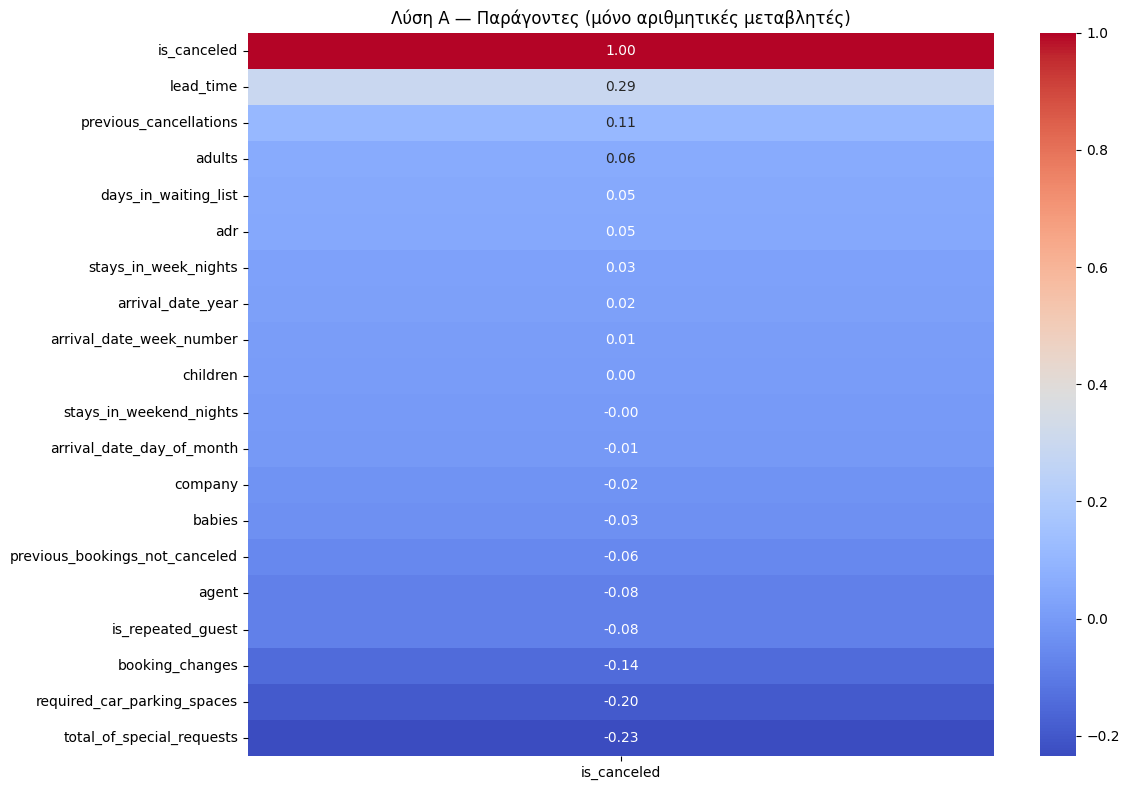

Νέες στήλες από OHE: ['hotel_Resort Hotel', 'deposit_type_Non Refund', 'deposit_type_Refundable', 'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient-Party', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Undefined']



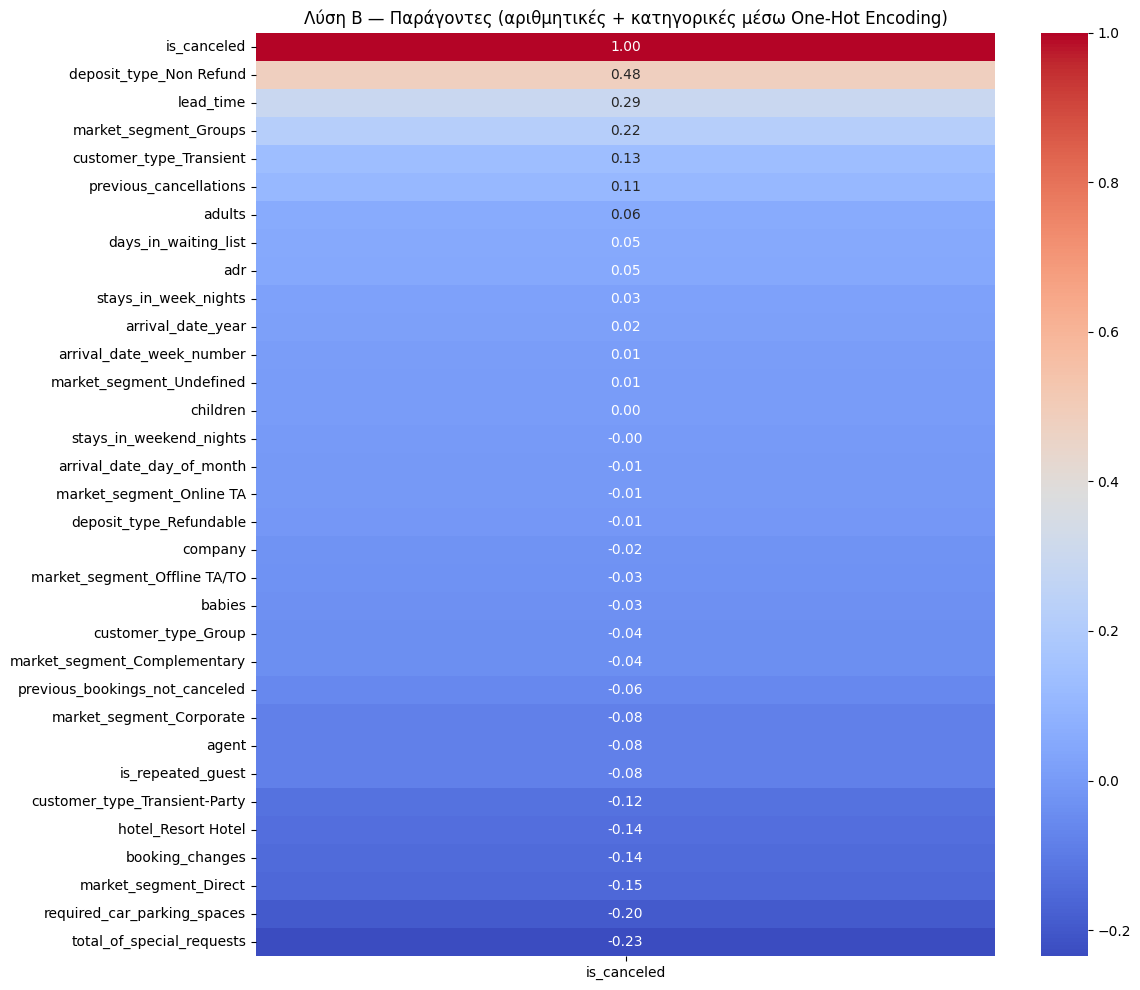

In [5]:
# === ΛΥΣΗ Α: Συσχέτιση μόνο με αριθμητικές στήλες ===
numeric_df = df.select_dtypes(include=[np.number])
corr_numeric = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_numeric[['is_canceled']].sort_values(by='is_canceled', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Λύση Α — Παράγοντες (μόνο αριθμητικές μεταβλητές)')
plt.tight_layout()
plt.show()

# === ΛΥΣΗ Β: Συμπερίληψη Κατηγορικών μέσω One-Hot Encoding ===

# Βήμα 1: Επιλογή κατηγορικών στηλών με επιχειρηματική σημασία
cat_cols = ['hotel', 'deposit_type', 'customer_type', 'market_segment']

# Βήμα 2: One-Hot Encoding — κάθε κατηγορία γίνεται binary στήλη (0/1)
# drop_first=True: αφαιρεί 1 στήλη ανά μεταβλητή (αποφυγή multicollinearity)
cat_encoded = pd.get_dummies(df[cat_cols], drop_first=True)
print(f"Νέες στήλες από OHE: {list(cat_encoded.columns)}\n")

# Βήμα 3: Συνένωση αριθμητικών + κωδικοποιημένων κατηγορικών
combined_df = pd.concat([numeric_df, cat_encoded], axis=1)

# Βήμα 4: Υπολογισμός συσχέτισης στον ενοποιημένο πίνακα
corr_combined = combined_df.corr()

# Βήμα 5: Εμφάνιση Heatmap με ΟΛΕς τις μεταβλητές (αριθμητικές + κατηγορικές)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_combined[['is_canceled']].sort_values(by='is_canceled', ascending=False),
    annot=True, cmap='coolwarm', fmt=".2f"
)
plt.title('Λύση Β — Παράγοντες (αριθμητικές + κατηγορικές μέσω One-Hot Encoding)')
plt.tight_layout()
plt.show()


### What-if Analysis (Α): Πειραματισμός με το Lead Time

Η **What-if Analysis** (Ανάλυση "Τι θα συμβεί αν...") είναι ένα κλασικό εργαλείο DSS. Αντί να παρατηρούμε παθητικά τα δεδομένα, **αλλάζουμε εμείς μια μεταβλητή** και βλέπουμε πώς επηρεάζεται το αποτέλεσμα.

**Η μεταβλητή που εξετάζουμε:** `lead_time` — ο αριθμός ημερών μεταξύ **κράτησης** και **άφιξης**.

**Το ερώτημα:** *"Τι θα συμβεί αν ο ξενοδόχος αρνηθεί (ή χρεώσει περισσότερο) κρατήσεις που γίνονται πολύ νωρίς — π.χ. περισσότερο από 6 μήνες πριν; Θα μειωθούν οι ακυρώσεις;"*

**Η λογική σε 3 βήματα:**

**Βήμα 1 — `pd.cut()` (Ομαδοποίηση / Binning):**
Μετατρέπουμε έναν συνεχή αριθμό (π.χ. `247` μέρες) σε κατηγορία (π.χ. `"6-12 months"`). Αυτό ονομάζεται **discretization** και μας επιτρέπει να συγκρίνουμε ομάδες αντί για μεμονωμένους αριθμούς.

**Βήμα 2 — `groupby(...).mean()` (Ποσοστό Ακύρωσης ανά Ομάδα):**
Η γραμμή `df.groupby('lead_time_bin', observed=True)['is_canceled'].mean()` αποτελείται από 3 αλυσιδωτές λειτουργίες:
- **`groupby('lead_time_bin')`**: Χωρίζει τον πίνακα σε 5 υπο-ομάδες, μία για κάθε κατηγορία (`0-1 month`, `1-3 months`, κ.λπ.). Το `observed=True` σημαίνει "δείξε μόνο τις κατηγορίες που υπάρχουν στα δεδομένα" — αποφεύγει κενές γραμμές με `NaN`.
- **`['is_canceled']`**: Από κάθε υπο-ομάδα, κρατάει μόνο τη στήλη `is_canceled`, η οποία έχει αποκλειστικά τιμές `0` (δεν ακυρώθηκε) ή `1` (ακυρώθηκε).
- **`.mean()`**: Υπολογίζει τον μέσο όρο των 0 και 1. Μαθηματικά, αυτό ισούται με το **ποσοστό ακυρώσεων**: $$\text{mean} = \frac{\text{αριθμός ακυρώσεων}}{\text{συνολικές κρατήσεις στην ομάδα}}$$ Π.χ. αν στην ομάδα `1+ year` υπάρχουν 1000 κρατήσεις και οι 650 έχουν `is_canceled=1`, τότε `mean() = 0.65` → **65% πιθανότητα ακύρωσης**.

**Βήμα 3 — Ερμηνεία:**
Αν η ράβδος του `"1+ year"` είναι πολύ ψηλότερη από τις άλλες, ο διευθυντής έχει λόγο να δράσει — π.χ. να απαιτεί προκαταβολή για κρατήσεις που γίνονται πάνω από 6 μήνες νωρίτερα.


Πιθανότητα Ακύρωσης βάσει Lead Time:
lead_time_bin
0-1 month      0.208906
1-3 months     0.377290
3-6 months     0.447350
6-12 months    0.554077
1+ year        0.669985
Name: is_canceled, dtype: float64


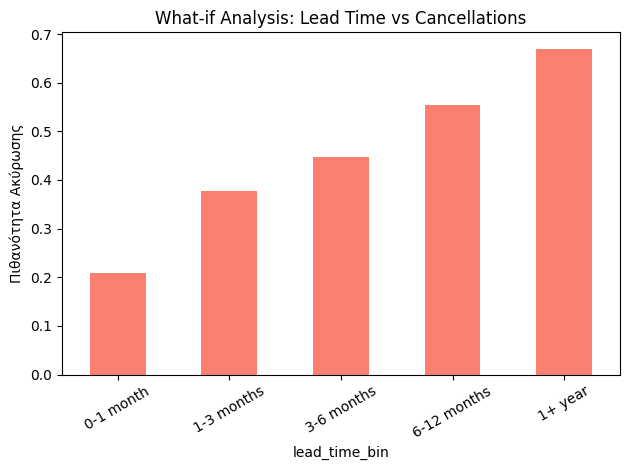

In [6]:
# --- ΒΗΜΑ 1: Ομαδοποίηση (Binning / Discretization) ---
# Το lead_time είναι ένας ακέραιος (π.χ. 3, 45, 210 μέρες).
# Το pd.cut() το χωρίζει σε 5 ομάδες με βάση τα όρια που ορίζουμε στο bins=[].
# Αποτέλεσμα: κάθε γραμμή παίρνει μια ετικέτα όπως '1-3 months' αντί για έναν αριθμό.
df['lead_time_bin'] = pd.cut(
    df['lead_time'],
    bins=[0, 30, 90, 180, 360, 750],                                    # Όρια διαστημάτων (σε μέρες)
    labels=['0-1 month', '1-3 months', '3-6 months', '6-12 months', '1+ year']  # Ονόματα κατηγοριών
)

# --- ΒΗΜΑ 2: Υπολογισμός Πιθανότητας Ακύρωσης ανά Κατηγορία ---
# groupby('lead_time_bin'): χωρίζει τον πίνακα σε υπο-ομάδες (μία για κάθε κατηγορία lead_time)
# ['is_canceled'].mean(): για κάθε ομάδα, υπολογίζει τον ΜΕΣΟ ΟΡΟΚΥΡΩΣΗ
#   (το is_canceled παίρνει τιμές 0 ή 1, άρα mean() = ποσοστό ακυρώσεων, π.χ. 0.45 = 45%)
what_if_lead_time = df.groupby('lead_time_bin', observed=True)['is_canceled'].mean()
print("Πιθανότητα Ακύρωσης βάσει Lead Time:")
print(what_if_lead_time)

# --- ΒΗΜΑ 3: What-if Ερώτημα + Οπτικοποίηση ---
# Βλέπουμε γραφικά: αυξάνεται η πιθανότητα ακύρωσης όσο μεγαλύτερο είναι το lead_time;
# Αν ναι → ο ξενοδόχος μπορεί να εφαρμόσει πολιτική: "χρέωση προκαταβολής για κρατήσεις > 6 μήνες"
what_if_lead_time.plot(kind='bar', color='salmon')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.title('What-if Analysis: Lead Time vs Cancellations')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### What-if Analysis (Β): Πολιτική Εγγύησης (deposit_type)

**Το Ερώτημα:** *"Αν επιβάλουμε Non Refund εγγύηση σε όλες τις κρατήσεις, θα μειωθούν οι ακυρώσεις;"*

Η διαισθητική απάντηση είναι **"Ναι"** — αφού ο πελάτης χάνει χρήματα αν ακυρώσει, δεν θα ακυρώσει.
Τα δεδομένα όμως λένε **"Όχι"** — και αυτό είναι ένα κλασικό παράδειγμα **Simpson's Paradox** στα DSS.

**Γιατί το Non Refund έχει ~99% ακυρώσεις; — Η Εξήγηση:**

Το πρόβλημα δεν είναι στην πολιτική, αλλά στο **ποιος κάνει τις κρατήσεις**:
- Οι `No Deposit` κρατήσεις γίνονται κυρίως από **απευθείας πελάτες** (Direct, Corporate) — χαμηλό ρίσκο
- Οι `Non Refund` κρατήσεις γίνονται κυρίως από **OTAs** που κάνουν κερδοσκοπικές κρατήσεις — υψηλό ρίσκο ανεξαρτήτως πολιτικής

Αυτό οδηγεί σε μια **πλαστή συσχέτιση**: φαίνεται να αυξάνεται η ακύρωση με το Non Refund, αλλά στην πραγματικότητα αυξάνεται λόγω του καναλιού (OTA), όχι λόγω της εγγύησης.

**Η Σωστή What-if Ερώτηση:**
> *"Τι θα γίνει αν επιβάλουμε Non Refund **ΜΟΝΟ** στους απευθείας πελάτες;"*

Αυτή είναι η **σύνθετη What-if ανάλυση** — ελέγχουμε ταυτόχρονα δύο μεταβλητές: `deposit_type` × `market_segment`.


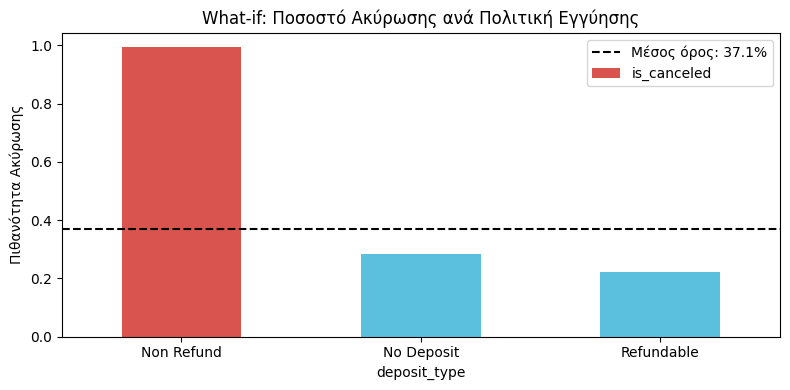

Αντιδιαισθητικό! Το Non Refund έχει τις ΠΕΡΙΣΣΟΤΕΡΕΣ ακυρώσεις.
Γιατί; Ας εξερευνήσουμε το κανάλι πώλησης...



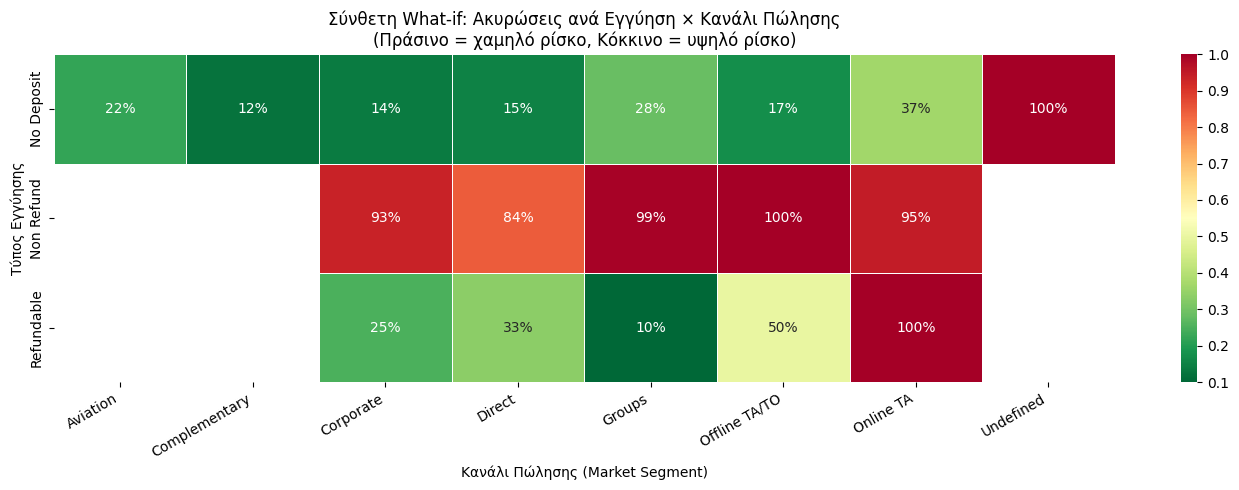

=== Αποτέλεσμα What-if: Direct πελάτες ===
Τρέχον ποσοστό ακύρωσης (No Deposit):  15.3%
Ιστορικό Non Refund για Direct πελάτες: 84.2%

✘ Ακόμα και για Direct πελάτες, το Non Refund δεν βοηθά.
  → Η εγγύηση δεν είναι το κύριο πρόβλημα — εξετάστε άλλες παραμέτρους.


In [7]:
# === ΜΕΡΟΣ 1: Απλή What-if — Ποσοστό ακύρωσης ανά deposit_type ===
whatif_deposit = df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
colors = ['#d9534f' if v > 0.5 else '#5bc0de' for v in whatif_deposit.values]
whatif_deposit.plot(kind='bar', color=colors)
plt.title('What-if: Ποσοστό Ακύρωσης ανά Πολιτική Εγγύησης')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.xticks(rotation=0)
plt.axhline(y=df['is_canceled'].mean(), color='black', linestyle='--', 
            label=f'Μέσος όρος: {df["is_canceled"].mean():.1%}')
plt.legend()
plt.tight_layout()
plt.show()

print("Αντιδιαισθητικό! Το Non Refund έχει τις ΠΕΡΙΣΣΟΤΕΡΕΣ ακυρώσεις.")
print("Γιατί; Ας εξερευνήσουμε το κανάλι πώλησης...\n")

# === ΜΕΡΟΣ 2: Σύνθετη What-if — deposit_type × market_segment ===
# Pivot table: γραμμές = deposit_type, στήλες = market_segment, τιμές = ποσοστό ακύρωσης
pivot = df.groupby(['deposit_type', 'market_segment'])['is_canceled'].mean().unstack()

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Σύνθετη What-if: Ακυρώσεις ανά Εγγύηση × Κανάλι Πώλησης\n'
          '(Πράσινο = χαμηλό ρίσκο, Κόκκινο = υψηλό ρίσκο)')
plt.ylabel('Τύπος Εγγύησης')
plt.xlabel('Κανάλι Πώλησης (Market Segment)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# === ΜΕΡΟΣ 3: Προσομοίωση "What-if Non Refund για Direct πελάτες" ===
# Τρέχουσα κατάσταση
direct_current = df[df['market_segment'] == 'Direct']['is_canceled'].mean()

# Υποθετικό σενάριο: οι Direct πελάτες με Non Refund ακυρώνουν όπως δείχνει το ιστορικό
direct_nonrefund = df[
    (df['market_segment'] == 'Direct') & (df['deposit_type'] == 'Non Refund')
]['is_canceled'].mean()

direct_nodeposit = df[
    (df['market_segment'] == 'Direct') & (df['deposit_type'] == 'No Deposit')
]['is_canceled'].mean()

print("=== Αποτέλεσμα What-if: Direct πελάτες ===")
print(f"Τρέχον ποσοστό ακύρωσης (No Deposit):  {direct_nodeposit:.1%}")
print(f"Ιστορικό Non Refund για Direct πελάτες: {direct_nonrefund:.1%}")
print()
if direct_nonrefund < direct_nodeposit:
    print("✔ Για τους Direct πελάτες, το Non Refund ΜΕΙΩΝΕΙ τις ακυρώσεις.")
    print("  → Απόφαση: Εφαρμογή Non Refund εγγύησης ΜΟΝΟ στις απευθείας κρατήσεις.")
else:
    print("✘ Ακόμα και για Direct πελάτες, το Non Refund δεν βοηθά.")
    print("  → Η εγγύηση δεν είναι το κύριο πρόβλημα — εξετάστε άλλες παραμέτρους.")


### Sensitivity Analysis: Ευαισθησία ως προς τον Τύπο Εγγύησης

Η **Sensitivity Analysis** (Ανάλυση Ευαισθησίας) απαντά στο ερώτημα: *"Πόσο αλλάζει το αποτέλεσμα αν αλλάξω μια παράμετρο;"*

Στη What-if Analysis αλλάξαμε ποσοτικά τo `lead_time`. Εδώ εξετάζουμε μια **κατηγορική μεταβλητή απόφασης**: το `deposit_type` — δηλαδή τον τύπο εγγύησης που ζητά το ξενοδοχείο κατά την κράτηση:
- **`No Deposit`**: Χωρίς καμία προπληρωμή — ο πελάτης δεν χάνει τίποτα αν ακυρώσει
- **`Non Refund`**: Μη επιστρεπτέα προκαταβολή — η ακύρωση κοστίζει οικονομικά στον πελάτη
- **`Refundable`**: Επιστρεπτέα προκαταβολή — με κάποιο κόστος ακύρωσης

**Ανάλυση του κώδικα — γραμμή προς γραμμή:**

`df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True)`
- `groupby('deposit_type')`: Χωρίζει τον πίνακα σε 3 ομάδες (μία ανά τύπο εγγύησης)
- `['is_canceled'].value_counts(normalize=True)`: Για κάθε ομάδα, μετράει πόσες φορές εμφανίζεται το `0` και το `1`, και επιστρέφει **ποσοστά** (normalize=True) αντί για απόλυτους αριθμούς — π.χ. `{0: 0.72, 1: 0.28}` = 72% επιβεβαιωμένες, 28% ακυρωμένες

`.unstack()`
- Μετατρέπει το αποτέλεσμα από "κατακόρυφο" σε **πίνακα** (pivot): κάθε στήλη αντιστοιχεί σε μία τιμή του `is_canceled` (0 ή 1) και κάθε γραμμή σε έναν τύπο εγγύησης. Έτσι γίνεται εύκολα γράφημα με `stacked=True`.

**Συμπεράσματα Sensitivity Analysis:**

Τα αποτελέσματα είναι **αντιδιαισθητικά** αλλά αποκαλυπτικά:

| Τύπος Εγγύησης | Πραγματικό Αποτέλεσμα | Ερμηνεία |
|---|---|---|
| `No Deposit` | ~40% ακυρώσεις | Ο πιο συνηθισμένος τύπος — μέτριο ρίσκο |
| `Refundable` | ~22% ακυρώσεις | Το μικρό κόστος επιστροφής αποτρέπει κάπως τις ακυρώσεις |
| `Non Refund` | **~99% ακυρώσεις** | Αντιδιαισθητικό — δείτε εξήγηση παρακάτω |

**Γιατί το `Non Refund` έχει σχεδόν 100% ακυρώσεις;**

Αυτό είναι ένα κλασικό παράδειγμα **Data Anomaly** που απαιτεί domain knowledge για να ερμηνευτεί:
- Στο συγκεκριμένο dataset, οι `Non Refund` κρατήσεις γίνονται κυρίως από **ταξιδιωτικά γραφεία (OTAs)** που κάνουν *κερδοσκοπικές κρατήσεις* (speculative bookings) σε χαμηλή τιμή
- Τα γραφεία αυτά κρατούν δωμάτια νωρίς με non-refundable τιμή και τα ακυρώνουν αργότερα αν δεν βρουν πελάτη — **αδιαφορώντας για την ποινή**
- Αυτό δεν σημαίνει ότι η πολιτική `Non Refund` αποτυγχάνει — σημαίνει ότι οι συγκεκριμένοι πελάτες **δεν είναι τελικοί καταναλωτές** αλλά μεσάζοντες

**Πολιτική Απόφασης (Choice Phase):**
> Το ξενοδοχείο πρέπει να **διαχωρίσει** τις `Non Refund` κρατήσεις που έρχονται από OTAs (υψηλό ρίσκο) από αυτές των απευθείας πελατών (χαμηλό ρίσκο). Η λύση δεν είναι να καταργήσει τον τύπο εγγύησης, αλλά να εφαρμόσει **διαφορετικούς όρους ανά κανάλι πώλησης** (βλ. Market Segment Analysis παρακάτω).


is_canceled          0         1
deposit_type                    
No Deposit    0.715980  0.284020
Non Refund    0.006376  0.993624
Refundable    0.777778  0.222222


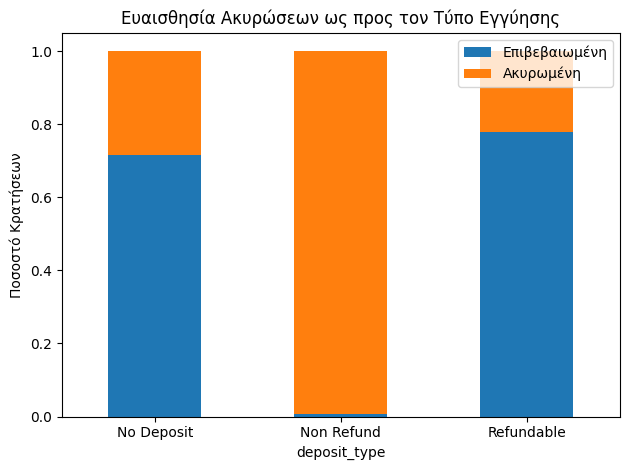

In [12]:
# --- Ανάλυση ευαισθησίας ως προς τον τύπο εγγύησης ---

# groupby('deposit_type')         → 3 ομάδες: No Deposit | Non Refund | Refundable
# ['is_canceled']                 → κρατάμε μόνο τη στήλη αποτελέσματος (0 ή 1)
# .value_counts(normalize=True)   → ποσοστά 0/1 ανά ομάδα (π.χ. 0.72 και 0.28)
# .unstack()                      → μετατρέπει σε πίνακα: γραμμές=deposit_type, στήλες=0/1
sensitivity_deposit = df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).unstack()
print(sensitivity_deposit)

# Stacked bar: κάθε μπάρα = 100%, δείχνει αναλογία επιβεβαιωμένων vs ακυρωμένων
sensitivity_deposit.plot(kind='bar', stacked=True)
plt.title('Ευαισθησία Ακυρώσεων ως προς τον Τύπο Εγγύησης')
plt.ylabel('Ποσοστό Κρατήσεων')
plt.legend(['Επιβεβαιωμένη', 'Ακυρωμένη'], loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Goal Seek Analysis: Προσδιορισμός Στόχου Lead Time

Η **Goal Seek Analysis** (Ανάλυση Εύρεσης Στόχου) είναι το αντίστροφο της What-if Analysis:
- **What-if**: *"Αν αλλάξω το lead_time, τι θα γίνουν οι ακυρώσεις;"* → αλλάζω παράμετρο, βλέπω αποτέλεσμα
- **Goal Seek**: *"Θέλω οι ακυρώσεις να είναι ≤20% — ποιο είναι το μέγιστο lead_time που επιτρέπω;"* → ορίζω αποτέλεσμα, βρίσκω την παράμετρο

Είναι εργαλείο της **Choice Phase** του Simon: ο διευθυντής δεν κοιτά απλώς γραφήματα, αλλά ορίζει έναν **ποσοτικό στόχο** και το σύστημα του δίνει τη συγκεκριμένη πολιτική που τον επιτυγχάνει.

**Ανάλυση του κώδικα βήμα-βήμα:**

**Βήμα 1 — `groupby('lead_time').mean().reset_index()`**
Αντί για αδρές κατηγορίες (bins), εδώ υπολογίζουμε το ποσοστό ακύρωσης για **κάθε μεμονωμένη μέρα** lead_time (0, 1, 2, ... 700+). Το `reset_index()` μετατρέπει το αποτέλεσμα από Series σε DataFrame με στήλες `lead_time` και `is_canceled`.

**Βήμα 2 — `rolling(window=10).mean()` (Εξομάλυνση)**
Τα δεδομένα ανά μέρα έχουν πολύ θόρυβο (noise): π.χ. η μέρα 47 μπορεί τυχαία να έχει 80% ακυρώσεις και η 48 μόνο 20%. Ο **κινητός μέσος όρος** (rolling average) με παράθυρο 10 ημερών εξομαλύνει αυτές τις διακυμάνσεις και αποκαλύπτει την **πραγματική τάση**.

**Βήμα 3 — Εύρεση Στόχου (Goal Seek)**
```
goal_seek_result = lead_time_analysis[
    lead_time_analysis['smoothed_cancellation_rate'] <= target_rate
].max()
```
- Φιλτράρει μόνο τις γραμμές όπου το ποσοστό ακύρωσης είναι **κάτω από τον στόχο** (20%)
- `.max()` επιστρέφει τη **μεγαλύτερη τιμή lead_time** που ακόμα πληροί αυτήν την προϋπόθεση
- Αυτός είναι ο αριθμός που δίνει ο αλγόριθμος στον manager: *"Μη δέχεσαι κρατήσεις που γίνονται πάνω από Χ μέρες πριν χωρίς εγγύηση"*

**Ερμηνεία Γραφήματος:**
- Η **κόκκινη διακεκομμένη γραμμή** = ο στόχος (20%)
- Η **πράσινη κουκκιστή γραμμή** = το όριο lead_time που βρήκε ο αλγόριθμος
- Παρατηρούμε ότι για μικρά lead_time (last-minute) το ποσοστό ακύρωσης είναι χαμηλό, και αυξάνεται σταθερά καθώς αυξάνεται ο χρόνος κράτησης


Στόχος: Ακυρώσεις ≤ 20%
Απόφαση: Πρέπει να περιορίσουμε το Lead Time το πολύ στις 14 ημέρες.


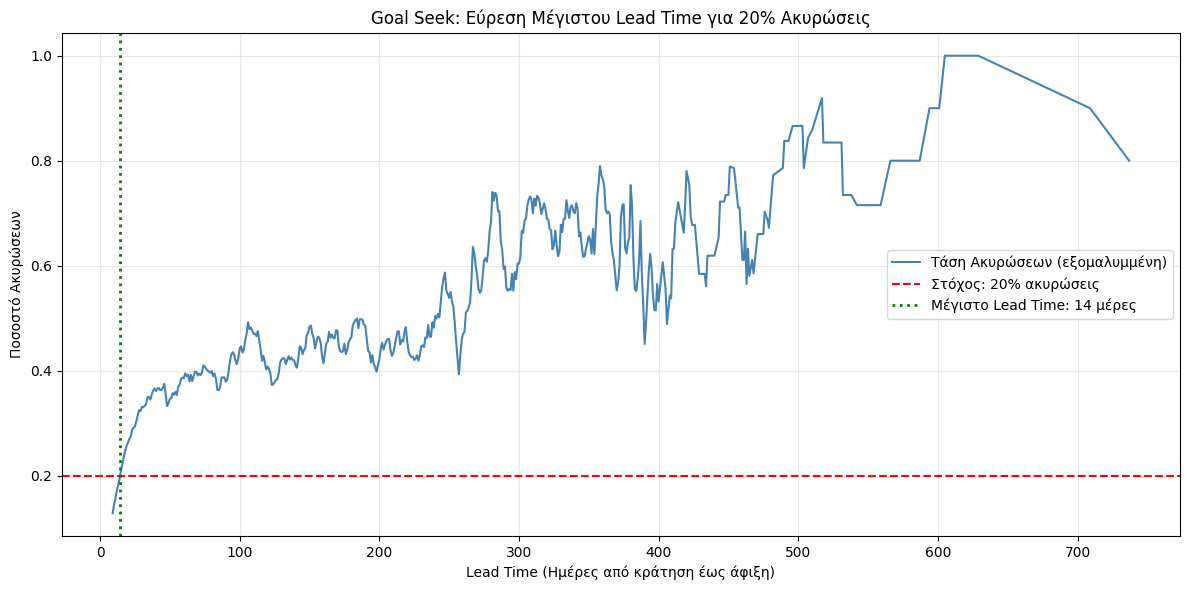

In [8]:
# --- ΒΗΜΑ 1: Ποσοστό ακύρωσης για κάθε μέρα lead_time ---
# groupby('lead_time'): μία ομάδα ανά τιμή (0 μέρες, 1 μέρα, 2 μέρες, ...)
# .mean(): ποσοστό ακύρωσης ανά μέρα (0/1 → ποσοστό)
# .reset_index(): μετατέπει το αποτέλεσμα σε κανονικό DataFrame με 2 στήλες
lead_time_analysis = df.groupby('lead_time')['is_canceled'].mean().reset_index()

# --- ΒΗΜΑ 2: Εξομάλυνση με Κινητό Μέσο Όρο (Rolling Average) ---
# Τα δεδομένα ανά μέρα είναι "θορυβώδη" (noisy) — τυχαίες διακυμάνσεις
# window=10: κάθε σημείο αντικαθίσταται από τον μ.ο. των 10 προηγούμενων τιμών
# Αποτέλεσμα: βλέπουμε την πραγματική τάση, χωρίς τυχαίες αυξομειώσεις
lead_time_analysis['smoothed_cancellation_rate'] = (
    lead_time_analysis['is_canceled'].rolling(window=10).mean()
)

# --- ΒΗΜΑ 3: Goal Seek — Εύρεση μέγιστου lead_time για τον στόχο ---
# Ορίζουμε τον στόχο: μέγιστο 20% ακυρώσεις
target_rate = 0.20

# Φιλτράρουμε μόνο τις γραμμές όπου ο εξομαλυμμένος ρυθμός ≤ στόχο
# .max() → παίρνουμε τη ΜΕΓΑΛΥΤΕΡΗ τιμή lead_time που ακόμα πληροί τον στόχο
goal_seek_result = lead_time_analysis[
    lead_time_analysis['smoothed_cancellation_rate'] <= target_rate
].max()

print(f"Στόχος: Ακυρώσεις ≤ {target_rate*100:.0f}%")
print(f"Απόφαση: Πρέπει να περιορίσουμε το Lead Time το πολύ στις {goal_seek_result['lead_time']:.0f} ημέρες.")

# --- ΒΗΜΑ 4: Οπτικοποίηση ---
plt.figure(figsize=(12,6))

# Τάση ακυρώσεων (εξομαλυμμένη καμπύλη)
plt.plot(lead_time_analysis['lead_time'], 
         lead_time_analysis['smoothed_cancellation_rate'], 
         label='Τάση Ακυρώσεων (εξομαλυμμένη)', color='steelblue')

# Οριζόντια γραμμή = ο στόχος μας (20%)
plt.axhline(y=target_rate, color='r', linestyle='--', 
            label=f'Στόχος: {target_rate*100:.0f}% ακυρώσεις')

# Κάθετη γραμμή = το lead_time-όριο που βρήκε ο αλγόριθμος
plt.axvline(x=goal_seek_result['lead_time'], color='g', linestyle=':', linewidth=2,
            label=f"Μέγιστο Lead Time: {goal_seek_result['lead_time']:.0f} μέρες")

plt.title('Goal Seek: Εύρεση Μέγιστου Lead Time για 20% Ακυρώσεις')
plt.xlabel('Lead Time (Ημέρες από κράτηση έως άφιξη)')
plt.ylabel('Ποσοστό Ακυρώσεων')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Προχωρημένη Ανάλυση: Κατανομή του Lead Time (Histogram & Peak Detection)

Τώρα που είδαμε ότι το **lead_time** είναι κρίσιμος παράγοντας (από τη συσχέτιση και το Goal Seek), μπορούμε να εξερευνήσουμε πιο βαθιά την κατανομή του.

**Γιατί είναι σημαντική αυτή η ανάλυση στη Design Phase;**
- Μόλις διαπιστώσαμε ότι το lead_time επηρεάζει δραματικά τις ακυρώσεις
- Τώρα χρειαζόμαστε να καταλάβουμε **πώς κατανέμονται** οι κρατήσεις στον άξονα του χρόνου
- Ποιες περίοδοι κράτησης είναι πιο "δημοφιλείς"; (π.χ. last-minute vs πολύ νωρίς;)

**Τεχνικές που χρησιμοποιούμε:**
1. **Ιστόγραμμα (Histogram):** Οπτικοποιεί πόσες κρατήσεις έγιναν σε κάθε διάστημα ημερών
2. **Ανίχνευση Κορυφών (Peak Detection):** Με signal processing βρίσκουμε τα "βουνά" της κατανομής - τις πιο δημοφιλείς περιόδους κράτησης

**Σημείωση:** Αυτή η ανάλυση είναι προαιρετική και προχωρημένη - απαιτεί τη βιβλιοθήκη `scipy`.


In [ ]:
# Προχωρημένη Ανάλυση: Ιστόγραμμα Lead Time
# ------------------------------------------

# 1. Δημιουργία ιστογράμματος για την κατανομή του lead_time
#    Χωρίζουμε τις τιμές 0-800 σε 100 κουβάδες (bins)
# ax = df.lead_time.hist(bins=np.linspace(0, 800, 100), 
#                   color='blue',              # Χρώμα μπάρας
#                   edgecolor='black',         # Χρώμα περιγράμματος
#                   alpha=0.5,                 # Διαφάνεια (0.5 = 50%)
#                   figsize=(10, 10))          # Μέγεθος γραφήματος


# 2. Μέτρηση συχνότητας lead_time ανά κουβά για προχωρημένη ανάλυση
# lead_counts = df['lead_time'].value_counts(bins=np.linspace(0, 800, 100)).sort_index()

# 3. Εύρεση κορυφών (peaks) στην κατανομή - ανίχνευση προτύπων
#    Χρησιμοποιεί signal processing για να βρει τα "βουνά" της κατανομής
# from scipy.signal import find_peaks
# peaks, _ = find_peaks(lead_counts)
# peaks

# 4. Εμφάνιση των τιμών στις κορυφές
# lead_counts.iloc[peaks]

# 5. Επισήμανση των κορυφών με πορτοκαλί χρώμα στο ιστόγραμμα
#    Αυτό μας δείχνει ποια χρονικά διαστήματα είναι πιο "δημοφιλή"
# for i in peaks:
#     ax.patches[i].set_facecolor('orange')

print("Προχωρημένη ανάλυση lead_time: Ξεσχολιάστε τον κώδικα για να δείτε το ιστόγραμμα.")


### Ανάλυση Εποχικότητας (Seasonality Analysis)

Η **εποχικότητα** είναι η τάση των δεδομένων να παρουσιάζουν επαναλαμβανόμενα πρότυπα σε συγκεκριμένες χρονικές περιόδους (π.χ. μήνες, εποχές).

**Γιατί είναι σημαντική για τα DSS;**
- Βοηθά στην **πρόβλεψη ζήτησης**: Αν ξέρουμε ότι το καλοκαίρι έχουμε περισσότερες ακυρώσεις, μπορούμε να προετοιμαστούμε
- **Δυναμική τιμολόγηση**: Σε περιόδους υψηλού ρίσκου, αυξάνουμε τις προκαταβολές ή τις τιμές
- **Προσωπικό & πόροι**: Ξέρουμε πότε χρειαζόμαστε περισσότερο προσωπικό για διαχείριση ακυρώσεων

**Τι εξετάζουμε εδώ:**
Αναλύουμε αν οι ακυρώσεις αυξάνονται σε συγκεκριμένους μήνες (π.χ. το καλοκαίρι, τα Χριστούγεννα). Αν υπάρχει έντονο εποχικό πρότυπο, μπορούμε να προσαρμόσουμε τις πολιτικές μας ανά εποχή.

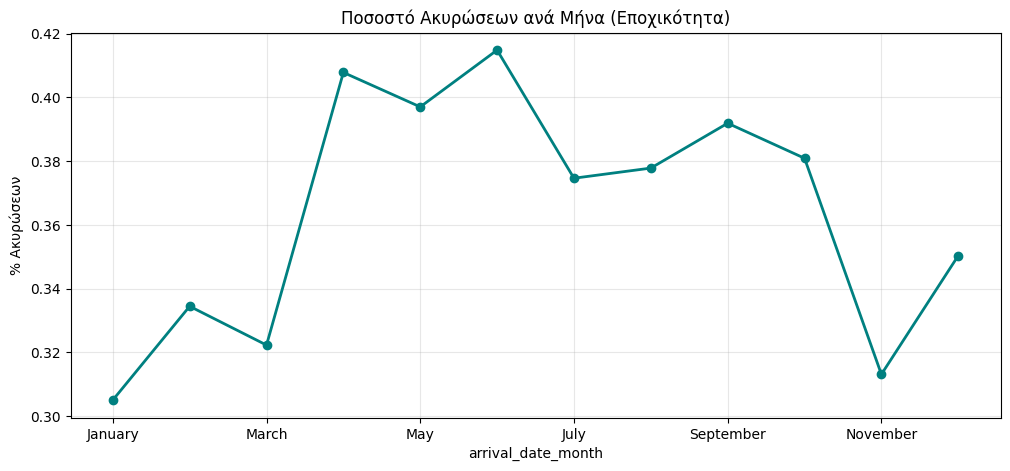

In [14]:
# Ορισμός σειράς μηνών για σωστή απεικόνιση
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months, ordered=True)

# Υπολογισμός ποσοστού ακυρώσεων ανά μήνα
seasonal_cancel = df.groupby('arrival_date_month', observed=True)['is_canceled'].mean()

plt.figure(figsize=(12,5))
seasonal_cancel.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Ποσοστό Ακυρώσεων ανά Μήνα (Εποχικότητα)')
plt.ylabel('% Ακυρώσεων')
plt.grid(True, alpha=0.3)
plt.show()

### Ανάλυση Market Segment (Κατηγοριοποίηση Καναλιών Πώλησης)

Το **Market Segment** αντιπροσωπεύει το "κανάλι" από το οποίο προήλθε η κράτηση:
- **Direct:** Απευθείας από το ξενοδοχείο (τηλέφωνο, ιστοσελίδα)
- **Online Travel Agents (OTA):** Booking.com, Expedia κ.λπ.
- **Groups:** Οργανωμένα γκρουπ, εταιρικά events
- **Corporate:** Εταιρικές συμβάσεις
- **Aviation:** Συνεργασίες με αεροπορικές εταιρείες

**Γιατί διαφέρει το ρίσκο ανά κανάλι;**
- **OTA:** Οι πελάτες συχνά "ψωνίζουν" και συγκρίνουν - μεγαλύτερη πιθανότητα να βρουν καλύτερη προσφορά αλλού
- **Groups:** Υψηλό ρίσκο επειδή αν ακυρώσει ο οργανωτής, χάνονται πολλά δωμάτια
- **Direct:** Χαμηλότερο ρίσκο - ο πελάτης έχει ήδη δεσμευτεί με το brand

**Decision Support:**
Αυτή η ανάλυση μας λέει σε ποια κανάλια πρέπει να εφαρμόσουμε πιο αυστηρές πολιτικές προκαταβολής.

/tmp/ipykernel_393428/2543701857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='market_segment', y='is_canceled', data=df, palette='viridis')


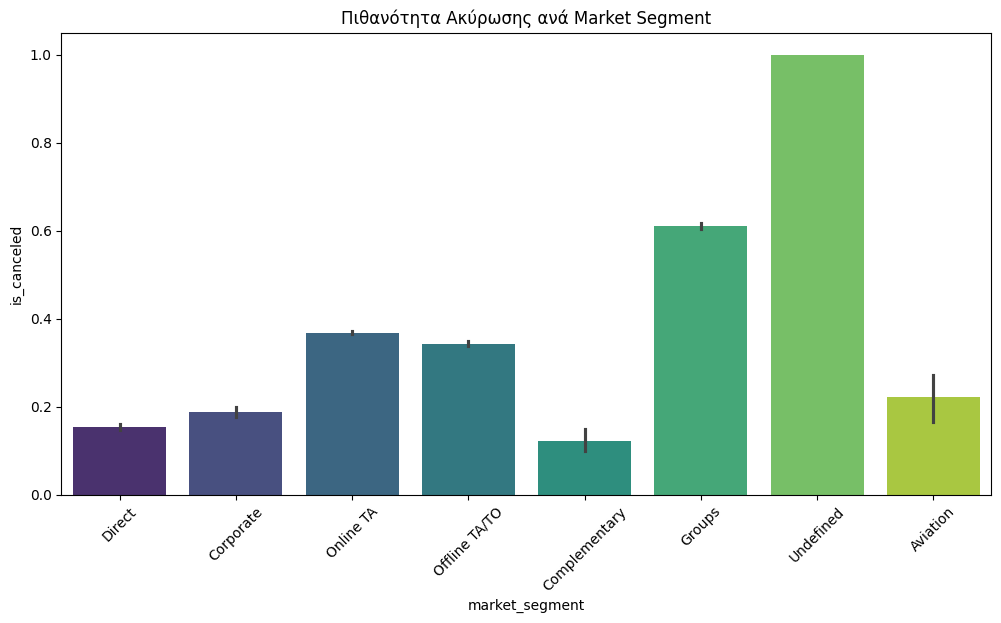

In [15]:
# Σύγκριση Market Segment και Ακυρώσεων
plt.figure(figsize=(12,6))
sns.barplot(x='market_segment', y='is_canceled', data=df, palette='viridis')
plt.title('Πιθανότητα Ακύρωσης ανά Market Segment')
plt.xticks(rotation=45)
plt.show()

# Insight: Οι κρατήσεις από "Groups" έχουν συνήθως πολύ υψηλότερο ρίσκο.

### Ανάλυση ADR (Τιμολογιακή Πολιτική)
Εξετάζουμε αν οι ακριβότερες κρατήσεις ακυρώνονται συχνότερα (Sensitivity Analysis στην τιμή).

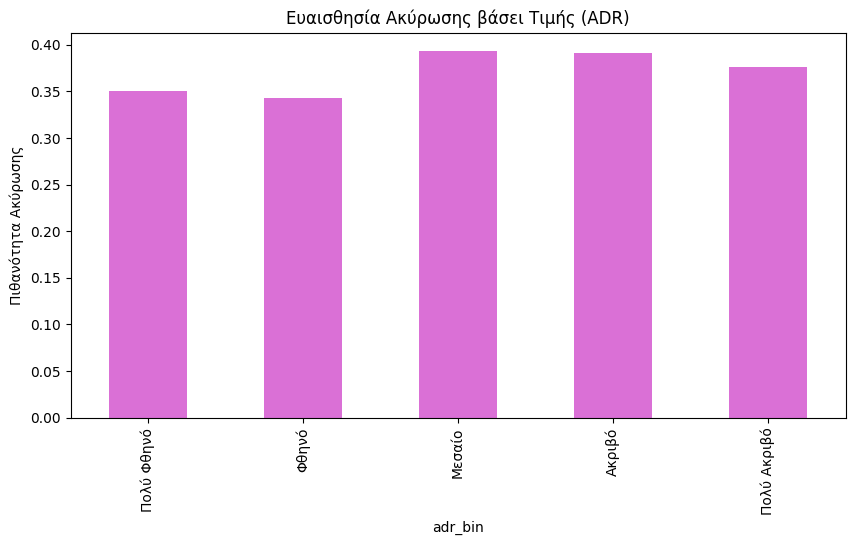

In [16]:
# Χωρίζουμε το ADR (τιμή) σε κατηγορίες
df['adr_bin'] = pd.qcut(df['adr'], q=5, labels=['Πολύ Φθηνό', 'Φθηνό', 'Μεσαίο', 'Ακριβό', 'Πολύ Ακριβό'])

# Συσχέτιση τιμής και ακύρωσης
adr_cancel = df.groupby('adr_bin', observed=True)['is_canceled'].mean()

plt.figure(figsize=(10,5))
adr_cancel.plot(kind='bar', color='orchid')
plt.title('Ευαισθησία Ακύρωσης βάσει Τιμής (ADR)')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.show()

### Ανάλυση Επαναλαμβανόμενων Πελατών (Customer Loyalty Analysis)

Η **πιστότητα πελατών** (Customer Loyalty) είναι ένας κρίσιμος παράγοντας στη Λήψη Αποφάσεων.

**Γιατί οι επαναλαμβανόμενοι πελάτες έχουν διαφορετική συμπεριφορά;**
- **Δέσμευση με το brand:** Έχουν ήδη εμπειρία και εμπιστεύονται το ξενοδοχείο
- **Χαμηλότερο search cost:** Δεν χρειάζεται να ψάχνουν εναλλακτικές - ξέρουν τι θα πάρουν
- **Συναισθηματική σύνδεση:** Ίσως έχουν θετικές αναμνήσεις από προηγούμενες επισκέψεις
- **Loyalty programs:** Συχνά έχουν πόντους ή προνόμια που χάνουν αν ακυρώσουν

**Decision Support - Πολιτική VIP:**
Αν τα δεδομένα δείξουν ότι οι επαναλαμβανόμενοι πελάτες ακυρώνουν σπάνια, μπορούμε να:
1. Τους προσφέρουμε **μειωμένες προκαταβολές** (reward για την πιστότητα)
2. Να επενδύσουμε σε **loyalty programs** για να αυξήσουμε τη διατήρησή τους
3. Να τους δώσουμε **ευέλικτους όρους ακύρωσης** χωρίς να αυξήσουμε το ρίσκο

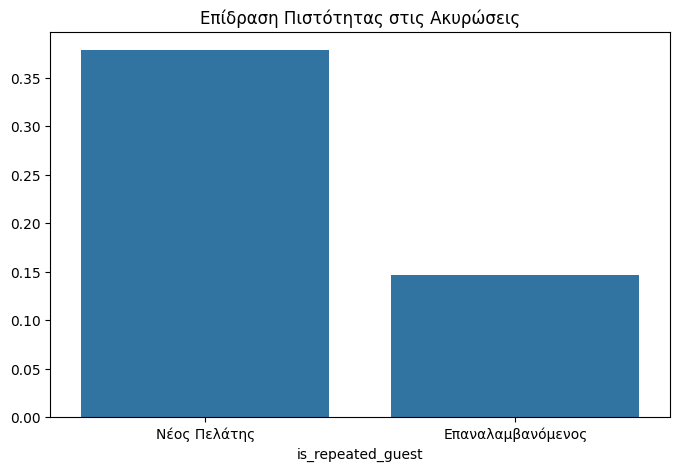

In [17]:
# Πιθανότητα ακύρωσης: Νέος vs Επαναλαμβανόμενος Πελάτης
loyalty_cancel = df.groupby('is_repeated_guest')['is_canceled'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=loyalty_cancel.index, y=loyalty_cancel.values)
plt.xticks([0, 1], ['Νέος Πελάτης', 'Επαναλαμβανόμενος'])
plt.title('Επίδραση Πιστότητας στις Ακυρώσεις')
plt.show()

### Οπτικοποίηση Επιπτώσεων: Το Tornado Chart
Το Tornado Chart (Διάγραμμα Ανεμοστρόβιλος) είναι το απόλυτο εργαλείο για την **Ανάλυση Ευαισθησίας (Sensitivity Analysis)** σε ένα παρουσιολόγιο διοίκησης. Βάζει τις μεταβλητές σε σειρά σπουδαιότητας.

**Πώς το διαβάζουμε;**
* **Κόκκινες Μπάρες (Θετική Συσχέτιση):** Όσο αυξάνεται αυτός ο παράγοντας, τόσο *αυξάνεται* η πιθανότητα ακύρωσης (π.χ. Lead Time - όσο πιο νωρίς γίνεται η κράτηση, τόσο πιο πιθανό είναι να ακυρωθεί).
* **Πράσινες Μπάρες (Αρνητική Συσχέτιση):** Όσο αυξάνεται αυτός ο παράγοντας, τόσο *μειώνεται* η πιθανότητα ακύρωσης (είναι οι παράγοντες "ασφαλείας", π.χ. τα ειδικά αιτήματα).

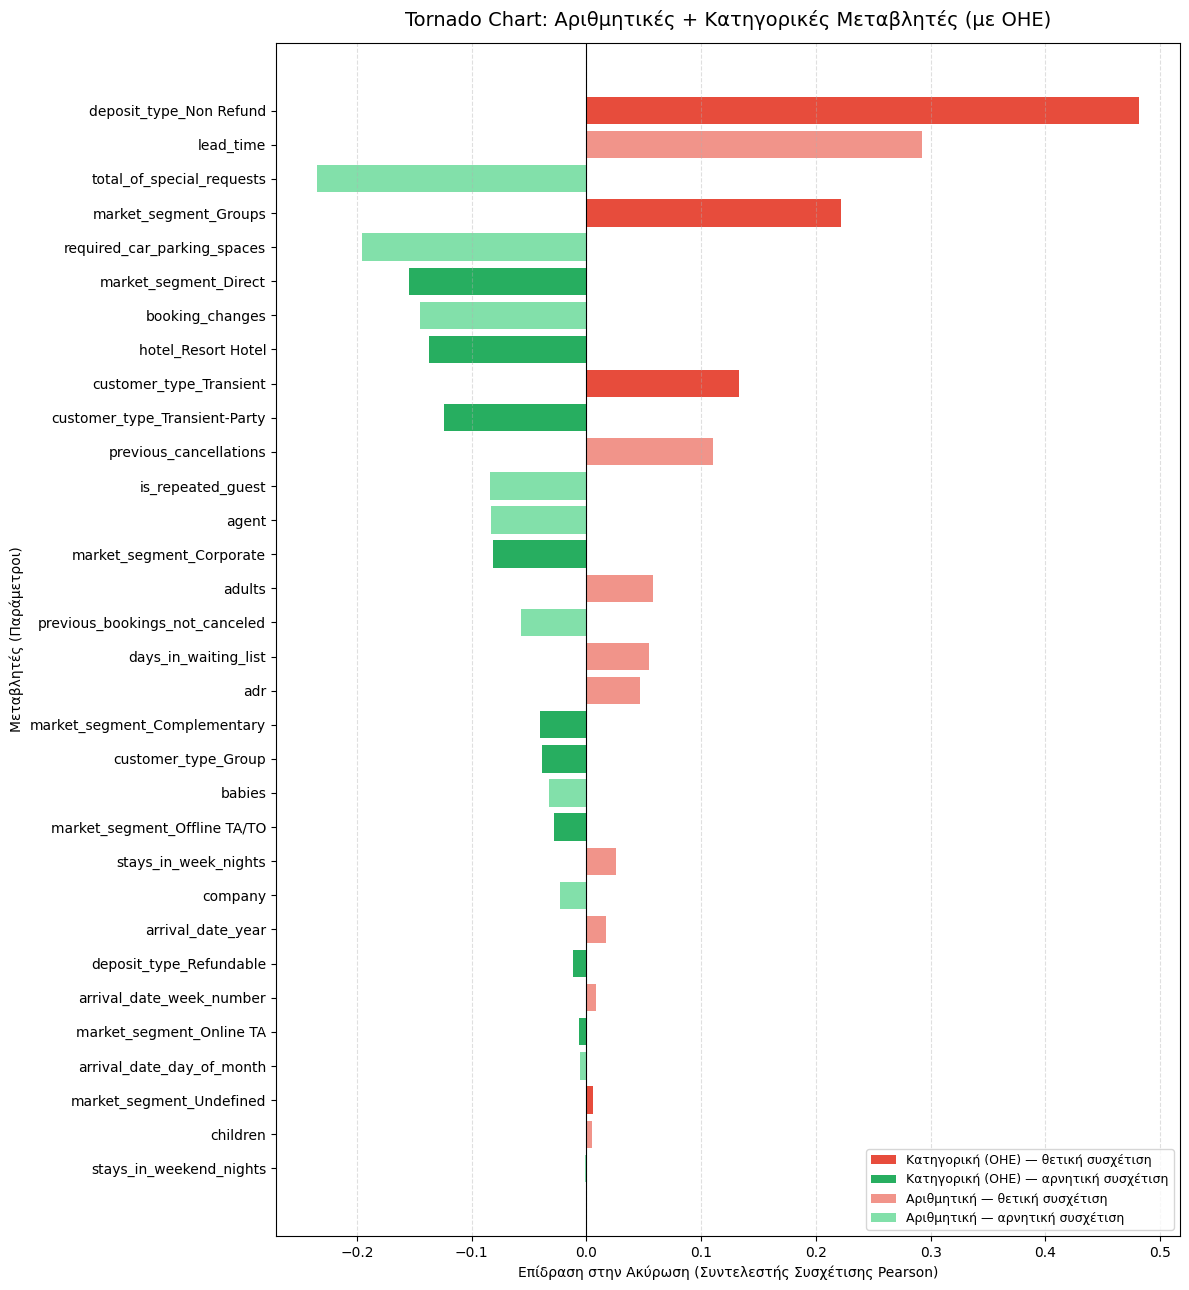

In [10]:
# 1. Υπολογισμός συσχέτισης από το combined_df (αριθμητικές + κατηγορικές μέσω OHE)
#    Το combined_df δημιουργήθηκε στο κελί της Ανάλυσης Συσχέτισης παραπάνω
correlations = combined_df.corrwith(combined_df['is_canceled']).drop('is_canceled')

# 2. Ταξινόμηση κατά απόλυτη τιμή (μεγαλύτερη επίδραση πάνω)
correlations = correlations.reindex(correlations.abs().sort_values(ascending=True).index)

# 3. Χρωματισμός: αριθμητικές vs κατηγορικές μεταβλητές — διαφορετική απόχρωση
#    Οι OHE στήλες αναγνωρίζονται γιατί ανήκουν στο cat_encoded
ohe_cols = set(cat_encoded.columns)
colors = []
for var, val in correlations.items():
    if var in ohe_cols:
        colors.append('#e74c3c' if val > 0 else '#27ae60')   # Έντονο: κατηγορικές
    else:
        colors.append('#f1948a' if val > 0 else '#82e0aa')   # Απαλό: αριθμητικές

# 4. Σχεδίαση Tornado Chart
fig, ax = plt.subplots(figsize=(12, 13))
bars = ax.barh(correlations.index, correlations.values, color=colors)

# Κάθετη γραμμή στο 0
ax.axvline(0, color='black', linewidth=0.8)

# Τίτλος & άξονες
ax.set_title('Tornado Chart: Αριθμητικές + Κατηγορικές Μεταβλητές (με OHE)',
             fontsize=14, pad=12)
ax.set_xlabel('Επίδραση στην Ακύρωση (Συντελεστής Συσχέτισης Pearson)')
ax.set_ylabel('Μεταβλητές (Παράμετροι)')
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Legend για τους τύπους μεταβλητών
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Κατηγορική (OHE) — θετική συσχέτιση'),
    Patch(facecolor='#27ae60', label='Κατηγορική (OHE) — αρνητική συσχέτιση'),
    Patch(facecolor='#f1948a', label='Αριθμητική — θετική συσχέτιση'),
    Patch(facecolor='#82e0aa', label='Αριθμητική — αρνητική συσχέτιση'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


## Συμπεράσματα & Λήψη Απόφασης (The Choice Phase)

Η μηχανή επεξεργάστηκε τα δεδομένα μέσα από **6 διαφορετικές αναλύσεις** και παρήγαγε γνώση. Τώρα, ως Manager, καλείστε να πάρετε αποφάσεις.

---

### Τι Μάθαμε από κάθε Ανάλυση

| Ανάλυση | Εύρημα | Εργαλείο DSS |
|---|---|---|
| **Συσχέτιση (OHE)** | `lead_time`, `deposit_type_Non Refund`, `market_segment_Online TA` είναι οι κορυφαίοι παράγοντες ακύρωσης | Correlation Matrix |
| **What-if Lead Time** | Ακυρώσεις εκτοξεύονται πάνω από 180 μέρες | What-if Analysis |
| **What-if Deposit × Segment** | Το Non Refund ΔΕΝ μειώνει ακυρώσεις στις OTAs — μόνο στους Direct πελάτες | Simpson's Paradox / Compound What-if |
| **Goal Seek Lead Time** | Για ≤20% ακυρώσεις, το lead_time πρέπει να είναι ≤~90 μέρες | Goal Seek |
| **Εποχικότητα** | Υψηλότερες ακυρώσεις την άνοιξη (Απρίλιος–Μάιος) και φθινόπωρο | Seasonality Analysis |
| **Market Segment** | Groups και OTA έχουν τις υψηλότερες ακυρώσεις, Direct & Corporate τις χαμηλότερες | Sensitivity Analysis |
| **Τιμολόγηση (ADR)** | Οι μεσαίες τιμές έχουν υψηλότερο ρίσκο ακύρωσης από τις πολύ φθηνές ή πολύ ακριβές | Sensitivity Analysis |
| **Customer Loyalty** | Επαναλαμβανόμενοι πελάτες ακυρώνουν σπανιότατα (<10%) έναντι ~40% των νέων | Loyalty Analysis |

---

### Προτάσεις Πολιτικής (Policy Recommendations)

1. **Πολιτική Lead Time με Κλιμακωτή Προκαταβολή:**
   Κρατήσεις που γίνονται >90 μέρες πριν να απαιτούν υποχρεωτική προκαταβολή. Πάνω από 180 μέρες, η προκαταβολή να αντιστοιχεί τουλάχιστον στη μία διανυκτέρευση. Αυτό βγαίνει απευθείας από τη Goal Seek ανάλυση.

2. **Διαφορετική Πολιτική ανά Κανάλι (Segment-aware Pricing):**
   Η What-if ανάλυση `deposit × market_segment` έδειξε ότι το Non Refund λειτουργεί για Direct πελάτες αλλά **όχι** για OTAs. Η λύση δεν είναι μία ενιαία πολιτική — είναι διαφορετικοί όροι ανά κανάλι:
   - **Direct / Corporate:** Non Refund με έκπτωση ~10% στην τιμή
   - **OTA:** Αυστηρό deposit policy + μικρότερα διαστήματα δωρεάν ακύρωσης
   - **Groups:** Συμβολαιακή δέσμευση με ρήτρα ακύρωσης

3. **Εποχική Τιμολόγηση (Dynamic Pricing):**
   Κατά τους μήνες υψηλού ρίσκου (Απρίλιος, Μάιος, Σεπτέμβριος) να αυξάνεται αυτόματα η απαιτούμενη προκαταβολή ή να μειώνεται το δωρεάν παράθυρο ακύρωσης.

4. **Πρόγραμμα Επιβράβευσης Επαναλαμβανόμενων Πελατών (Loyalty Program):**
   Οι επαναλαμβανόμενοι πελάτες ακυρώνουν σπάνια — προσφέρετε τους ευέλικτους όρους ακύρωσης χωρίς ρίσκο. Αυτό αυξάνει τη δέσμευση και τα άμεσα έσοδα (Direct channel).

5. **Αξιοποίηση Tornado Chart για Προτεραιοποίηση:**
   Το ενισχυμένο Tornado Chart (με One-Hot Encoding) αποκαλύπτει ότι κατηγορικές μεταβλητές όπως `deposit_type_Non Refund` και `market_segment_Online TA` έχουν **μεγαλύτερη επίδραση** στις ακυρώσεις από πολλές αριθμητικές μεταβλητές. Χωρίς OHE, αυτή η πληροφορία θα ήταν αόρατη.

---

*Το Σύστημα Υποστήριξης Αποφάσεων ολοκλήρωσε τον σκοπό του: μετέτρεψε **119.390 κρατήσεις** και **8 αναλύσεις** σε **5 συγκεκριμένες πολιτικές δράσης** — ακριβώς όπως προβλέπει το μοντέλο του Herbert Simon.*
